# SMR multilink modelization


Combined Heat and Power (CHP) with fixed heat-power ratio. 

the following code is based in a PyPSA CHP multilink [example](https://pypsa.readthedocs.io/en/latest/examples/chp-fixed-heat-power-ratio.html) that demonstrates a Link component with more than one bus output (“bus2” in this case).

The SMR_CHP must be heat-following because there is no other supply of heat to the bus "Industry Electricity heat”.

In [87]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import pypsa

sns.set(rc={"figure.figsize": (9, 5)})

In [104]:
network = pypsa.Network() # Creates empty PyPSA network object called network

network.add("Carrier",
      "Gas_CHP",
      #co2_emissions=cost.loc["CCGT","carbon_intensity"]
      )
network.add("Carrier",
      "SMR_CHP",
      #co2_emissions=cost.loc["CCGT","carbon_intensity"]
      )
network.add("Carrier",
      "heat",
      #co2_emissions=cost.loc["CCGT","carbon_intensity"]
      )
network.add("Carrier",
      "electricity",
      #co2_emissions=cost.loc["CCGT","carbon_intensity"]
      )

network.add("Bus", "Industry Electricity", carrier="electricity")
network.add("Bus", "Industry Heat", carrier="heat")
network.add("Bus", "Nuclear_Fuel", carrier="SMR_CHP")
network.add("Bus", "Spain gas", carrier="Gas_CHP")


network.add("Store", "Nuclear_Fuel", 
       e_initial=1e10, 
       e_nom=1e10, 
       bus="Nuclear_Fuel")

network.add("Store", "Spain gas", 
       e_initial=1e10,   # Energy before the snapshots in the OPF (Optimized power Flow).
       e_nom=1e10,       # Nominal energy capacity
       bus="Spain gas")

network.add(
    "Link",
    "Gas_CHP1",               
    bus0="Spain gas",
    bus1="Industry Electricity",
    #bus2="Industry Heat",
    #carrier="Gas_CHP",
    p_nom_extendable=True,
    capital_cost=59000,
    efficiency=0.30,
    #efficiency2=0.35,
)

network.add(
    "Link",
    "Gas_CHP2",               
    bus0="Spain gas",
    #bus1="Industry Electricity",
    bus1="Industry Heat", # Este sería el bus2
    #carrier="Gas_CHP",
    p_nom_extendable=True,
    capital_cost=59999,
    #efficiency=0.30,
    efficiency=0.35, # Este sería el efficiency2
)

network.add(
    "Link",
    "SMR_CHP",
    bus0="Nuclear_Fuel",
    bus1="Industry Electricity",
    bus2="Industry Heat",
    carrier="SMR_CHP",
    p_nom_extendable=True,
    capital_cost=14000,
    efficiency=0.35,
    efficiency2=0.35,
)
network.add("Load", "Industry Electricity Load", bus="Industry Electricity", p_set=5)
network.add("Load", "Industry Heat Load", bus="Industry Heat", p_set=3)


Index(['Industry Heat Load'], dtype='object')

In [97]:
# Define a funcion for visualizing the LOPF
def run_lopf():
    network.optimize()
    df = pd.concat(
        [
            network.generators_t.p.loc["now"],
            network.links_t.p0.loc["now"],
            network.loads_t.p.loc["now"],
        ],
        keys=["Generators", "Links", "Line"],
        names=["Component", "index"],
    ).reset_index(name="Production")

    sns.barplot(data=df, x="index", y="Production", hue="Component")
    plt.title(f"Objective: {network.objective}")
    plt.xticks(rotation=90)
    plt.tight_layout()

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.05s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 10 primals, 19 duals
Objective: 5.13e+05
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-energy_balance were not assigned to the network.


Unnamed PyPSA Network
---------------------
Components:
 - Bus: 4
 - Carrier: 4
 - Link: 3
 - Load: 2
 - Store: 2
Snapshots: 1

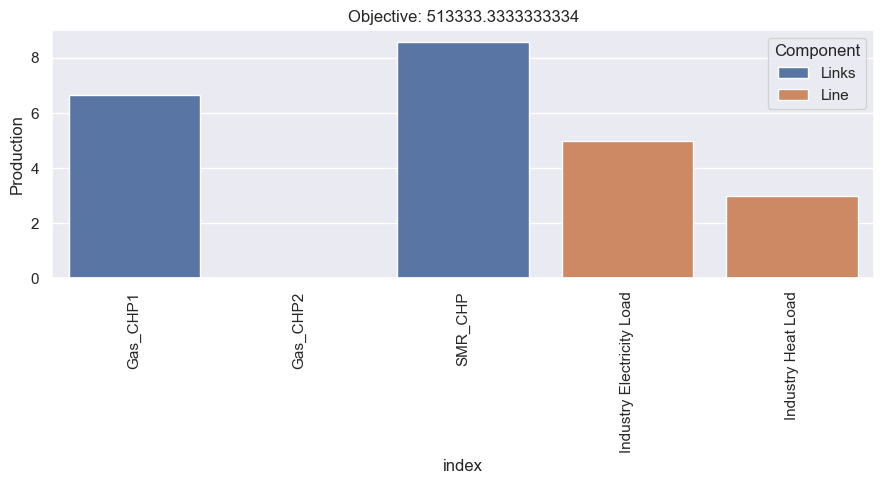

In [105]:
run_lopf()
network #view the network network

Note that negative values for network.links_t.p1 indicate that the link is injecting power into bus1 (This aligns with PyPSA's [convention](https://pypsa.readthedocs.io/en/latest/user-guide/design.html#sign-conventions) where power injected into a bus is considered negative, while power withdrawn from a bus is positive). 

- network.links_t.p0 # energy flows through the input bus (bus0) in each link (for each snapshot) CONSUMO DE COMBUSTIBLE
- network.links_t.p1 # energy flows through the output bus1 (bus1) in each link (for each snapshot) ENERGY GENERATION (CONVERSION)
- network.links_t.p2 # energy flows through the output bus2 (bus2) in each link (for each snapshot) ENERGY GENERATION (CONVERSION)

<!-- Note that `negative values` for network.links_t.p1 indicate that the link is injecting power into bus1 (This aligns with PyPSA's [convention](https://pypsa.readthedocs.io/en/latest/user-guide/design.html#sign-conventions) where power injected into a bus is considered negative, while power withdrawn from a bus is positive).

Here there is a brief explanation for each of the following code lines: 
- network.links_t.p0: `energy flows through the input bus (bus0) in each link (for each snapshot) CONSUMO DE COMBUSTIBLE`
- network.links_t.p1: `energy flows through the output bus1 (bus1) in each link (for each snapshot) ENERGY GENERATION (CONVERSION)`
- network.links_t.p2: `energy flows through the output bus2 (bus2) in each link (for each snapshot) ENERGY GENERATION (CONVERSION)` -->

In [92]:
print("SMR Electricity Output:", network.links_t.p1["SMR_CHP"].sum())  # -70 MW
print("SMR Heat Output:", network.links_t.p2["SMR_CHP"].sum())         # -108 MW
print("SMR Uranium Fuel Consumption:", network.links_t.p0["SMR_CHP"].sum())    # +314.3 MW

SMR Electricity Output: 0.0
SMR Heat Output: 0.0
SMR Uranium Fuel Consumption: 0.0


In [95]:
print("Gas_CHP1 Electricity Output:", network.links_t.p1["Gas_CHP1"].sum())
print("Gas_CHP1 Gas Consumption:", network.links_t.p0["Gas_CHP1"].sum())

Gas_CHP1 Electricity Output: -5.0
Gas_CHP1 Gas Consumption: 16.666666666666668


# End of the fuctional example

<!-- 
Starts SMR model versión2 with network `n2`

## Note: 
About de network initialization (can be useful for some future research)

**Network Initialization**: `n1 = pypsa.Network(url)`
   - Creates a PyPSA `Network` object `n1`
   - Automatically downloads and loads the pre-configured energy system model containing:
     - Buses (energy nodes)
     - Generators (power plants)
     - Loads (energy demands)
     - Transmission lines
     - Time-dependent constraints

Key Features of This Approach:
- **Reproducibility**: Loads a standardized benchmark model
- **Time-Saving**: Avoids manual network construction (~1000+ lines of setup code)
- **Research-Ready**: Contains realistic European power system data (likely from [PyPSA-Eur](https://pypsa-eur.readthedocs.io/)) -->